In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import pandas as pd
# https://www.kaggle.com/datasets/tamber/steam-video-games
dataset = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/Recommendation_systems/steam-200k.csv',
    header=None,
    names=['user-id', 'game-title', 'behavior-name', 'value', 'timestamp'],
)
dataset

,user-id,game-title,behavior-name,value,timestamp
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0
...,...,...,...,...,...
199995,128470551,Titan Souls,play,1.5,0
199996,128470551,Grand Theft Auto Vice City,purchase,1.0,0
199997,128470551,Grand Theft Auto Vice City,play,1.5,0
199998,128470551,RUSH,purchase,1.0,0


In [26]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Константы
RANDOM_STATE = 42
TEST_SIZE = 0.2

Размер обработанного датасета: (70477, 7)
Уникальных пользователей: 11350
Уникальных игр: 3600


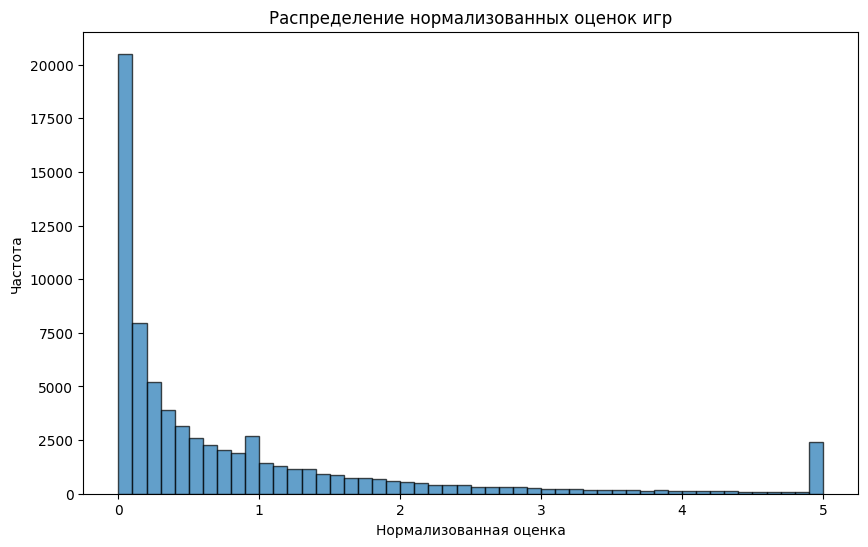

In [27]:
# Этап 1: Загрузка и предобработка данных
def preprocess_data(dataset):
    # Оставляем только игровые сессии (play)
    play_data = dataset[dataset['behavior-name'] == 'play'].copy()
    play_data = play_data.drop_duplicates(['user-id', 'game-title'], keep='last')

    # Вычисляем нормализованную оценку
    game_avg_playtime = play_data.groupby('game-title')['value'].mean().rename('avg_playtime')
    play_data = play_data.merge(game_avg_playtime, on='game-title')
    play_data['normalized_rating'] = play_data['value'] / play_data['avg_playtime']
    play_data['normalized_rating'] = play_data['normalized_rating'].clip(upper=5)

    return play_data

play_data = preprocess_data(dataset)
print("Размер обработанного датасета:", play_data.shape)
print("Уникальных пользователей:", play_data['user-id'].nunique())
print("Уникальных игр:", play_data['game-title'].nunique())

# Визуализация распределения оценок
plt.figure(figsize=(10, 6))
plt.hist(play_data['normalized_rating'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение нормализованных оценок игр')
plt.xlabel('Нормализованная оценка')
plt.ylabel('Частота')
plt.show()

In [28]:
# Этап 2: Разделение на обучающую и тестовую выборки
def create_train_test_matrices(play_data, test_size=0.2):
    # Создаем полную матрицу пользователь-игра
    full_matrix = play_data.pivot_table(
        index='user-id',
        columns='game-title',
        values='normalized_rating',
        fill_value=0
    )

    # Создаем маску ненулевых оценок для разделения
    nonzero_mask = full_matrix > 0
    nonzero_indices = np.where(nonzero_mask)

    # Случайно разделяем ненулевые оценки на train/test
    train_indices, test_indices = train_test_split(
        range(len(nonzero_indices[0])),
        test_size=test_size,
        random_state=RANDOM_STATE
    )

    # Создаем train матрицу
    train_matrix = full_matrix.copy().values
    for idx in test_indices:
        i, j = nonzero_indices[0][idx], nonzero_indices[1][idx]
        train_matrix[i, j] = 0

    # Создаем test матрицу (только тестовые оценки, остальные 0)
    test_matrix = np.zeros_like(train_matrix)
    for idx in test_indices:
        i, j = nonzero_indices[0][idx], nonzero_indices[1][idx]
        test_matrix[i, j] = full_matrix.iloc[i, j]

    return full_matrix, pd.DataFrame(train_matrix, index=full_matrix.index, columns=full_matrix.columns), test_matrix

full_matrix, train_matrix, test_matrix = create_train_test_matrices(play_data, TEST_SIZE)
print("Размер train матрицы:", train_matrix.shape)
print("Количество тестовых оценок:", np.count_nonzero(test_matrix))

Размер train матрицы: (11350, 3600)
Количество тестовых оценок: 14096


In [29]:
# Этап 3: Реализация алгоритмов рекомендаций
def matrix_factorization_prediction(ratings_matrix, n_factors=50):
    user_ratings_mean = np.mean(ratings_matrix.values, axis=1)
    ratings_diff = ratings_matrix.values - user_ratings_mean.reshape(-1, 1)

    U, sigma, Vt = svds(ratings_diff, k=n_factors)
    sigma = np.diag(sigma)

    predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)
    return predicted_ratings

def content_based_prediction(ratings_matrix):
    """Оптимизированная content-based фильтрация с векторизованными операциями"""
    # Вычисляем косинусную схожесть между играми
    game_similarity = cosine_similarity(ratings_matrix.T)

    # Создаем маску для уже оцененных игр
    user_ratings = ratings_matrix.values
    rated_mask = (user_ratings > 0).astype(float)

    # Векторизованное вычисление предсказаний
    # Для каждого пользователя: сумма(схожесть * оценки) / сумма(|схожесть|)
    numerator = np.dot(user_ratings, game_similarity)
    denominator = np.dot(rated_mask, np.abs(game_similarity))

    # Избегаем деления на ноль
    denominator[denominator == 0] = 1

    predicted_ratings = numerator / denominator
    return predicted_ratings

def hybrid_recommendation(ratings_matrix, n_factors=50, alpha=0.7):
    mf_pred = matrix_factorization_prediction(ratings_matrix, n_factors)
    cb_pred = content_based_prediction(ratings_matrix)
    hybrid_pred = alpha * mf_pred + (1 - alpha) * cb_pred
    return hybrid_pred, mf_pred, cb_pred

def calculate_rmse(predicted_ratings, actual_ratings):
    mask = actual_ratings > 0
    if np.sum(mask) == 0:
        return np.inf
    return np.sqrt(mean_squared_error(actual_ratings[mask], predicted_ratings[mask]))

=== Исследование параметров матричной факторизации ===
Факторы: 5, RMSE: 1.3951
Факторы: 10, RMSE: 1.4002
Факторы: 15, RMSE: 1.3922
Факторы: 20, RMSE: 1.3916
Факторы: 25, RMSE: 1.3915
Факторы: 30, RMSE: 1.3928
Факторы: 35, RMSE: 1.3936
Факторы: 40, RMSE: 1.3943
Факторы: 45, RMSE: 1.3961
Факторы: 50, RMSE: 1.3966
Факторы: 55, RMSE: 1.3970
Факторы: 60, RMSE: 1.3969
Факторы: 65, RMSE: 1.3966
Факторы: 70, RMSE: 1.3975
Факторы: 75, RMSE: 1.3982
Факторы: 80, RMSE: 1.3990
Факторы: 85, RMSE: 1.4004
Факторы: 90, RMSE: 1.4013
Факторы: 95, RMSE: 1.4015
Факторы: 100, RMSE: 1.4026


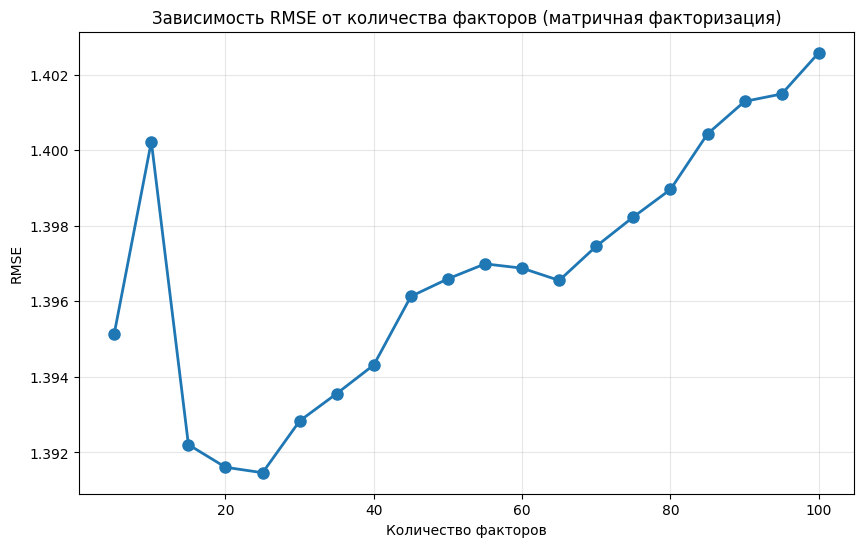

Оптимальное количество факторов: 25


In [30]:
# Этап 4: Исследование параметров матричной факторизации
print("=== Исследование параметров матричной факторизации ===")
factors_range = range(5, 101, 5)
mf_rmse_results = []

for n_factors in factors_range:
    mf_pred = matrix_factorization_prediction(train_matrix, n_factors)
    rmse = calculate_rmse(mf_pred, test_matrix)
    mf_rmse_results.append(rmse)
    print(f"Факторы: {n_factors}, RMSE: {rmse:.4f}")

# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.plot(factors_range, mf_rmse_results, marker='o', linewidth=2, markersize=8)
plt.title('Зависимость RMSE от количества факторов (матричная факторизация)')
plt.xlabel('Количество факторов')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.show()

# Оптимальное количество факторов
optimal_factors = factors_range[np.argmin(mf_rmse_results)]
print(f"Оптимальное количество факторов: {optimal_factors}")


=== Исследование параметра alpha для гибридной системы ===
Alpha: 0.00, RMSE: 1.250923
Alpha: 0.05, RMSE: 1.240213
Alpha: 0.10, RMSE: 1.231346
Alpha: 0.15, RMSE: 1.224360
Alpha: 0.20, RMSE: 1.219290
Alpha: 0.25, RMSE: 1.216158
Alpha: 0.30, RMSE: 1.214979
Alpha: 0.35, RMSE: 1.215760
Alpha: 0.40, RMSE: 1.218496
Alpha: 0.45, RMSE: 1.223175
Alpha: 0.50, RMSE: 1.229774
Alpha: 0.55, RMSE: 1.238262
Alpha: 0.60, RMSE: 1.248601
Alpha: 0.65, RMSE: 1.260746
Alpha: 0.70, RMSE: 1.274645
Alpha: 0.75, RMSE: 1.290241
Alpha: 0.80, RMSE: 1.307473
Alpha: 0.85, RMSE: 1.326278
Alpha: 0.90, RMSE: 1.346589
Alpha: 0.95, RMSE: 1.368341
Alpha: 1.00, RMSE: 1.391464


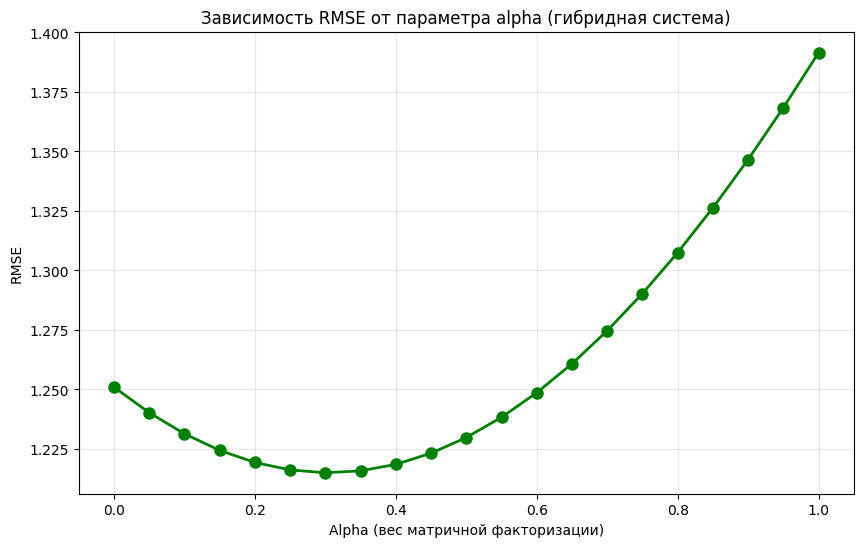

Оптимальное значение alpha: 0.3


In [35]:
# Этап 5: Исследование параметра alpha для гибридной системы
print("\n=== Исследование параметра alpha для гибридной системы ===")
alpha_range = list(map(lambda x: float(x) / 100.0, range(0, 101, 5)))
hybrid_rmse_results = []

for alpha in alpha_range:
    hybrid_pred, _, _ = hybrid_recommendation(train_matrix, optimal_factors, alpha)
    rmse = calculate_rmse(hybrid_pred, test_matrix)
    hybrid_rmse_results.append(rmse)
    print(f"Alpha: {alpha:.2f}, RMSE: {rmse:.6f}")

# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.plot(alpha_range, hybrid_rmse_results, marker='o', linewidth=2, markersize=8, color='green')
plt.title('Зависимость RMSE от параметра alpha (гибридная система)')
plt.xlabel('Alpha (вес матричной факторизации)')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.show()

# Оптимальное значение alpha
optimal_alpha = alpha_range[np.argmin(hybrid_rmse_results)]
print(f"Оптимальное значение alpha: {optimal_alpha}")


=== Сравнение алгоритмов с оптимальными параметрами ===
Результаты сравнения на тестовой выборке:
Матричная факторизация (факторы=25): 1.3915
Content-based фильтрация: 1.2509
Гибридная система (alpha=0.3): 1.2150


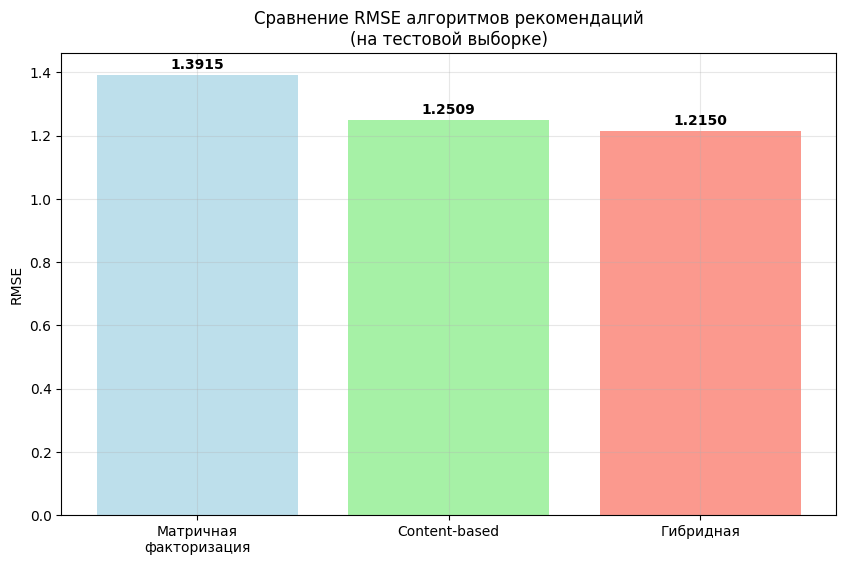

In [36]:
# Этап 6: Сравнение алгоритмов с оптимальными параметрами
print("\n=== Сравнение алгоритмов с оптимальными параметрами ===")

# Вычисление предсказаний для всех алгоритмов
hybrid_pred, mf_pred, cb_pred = hybrid_recommendation(train_matrix, optimal_factors, optimal_alpha)

# Вычисление RMSE
mf_rmse = calculate_rmse(mf_pred, test_matrix)
cb_rmse = calculate_rmse(cb_pred, test_matrix)
hybrid_rmse = calculate_rmse(hybrid_pred, test_matrix)

print("Результаты сравнения на тестовой выборке:")
print(f"Матричная факторизация (факторы={optimal_factors}): {mf_rmse:.4f}")
print(f"Content-based фильтрация: {cb_rmse:.4f}")
print(f"Гибридная система (alpha={optimal_alpha}): {hybrid_rmse:.4f}")

# Визуализация сравнения
methods = ['Матричная\nфакторизация', 'Content-based', 'Гибридная']
rmse_values = [mf_rmse, cb_rmse, hybrid_rmse]

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, rmse_values, color=['lightblue', 'lightgreen', 'salmon'], alpha=0.8)
plt.title('Сравнение RMSE алгоритмов рекомендаций\n(на тестовой выборке)')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)

for bar, value in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

plt.show()

In [37]:
# Этап 7: Пример рекомендаций для 5 случайных пользователей
print("\n=== Пример рекомендаций для 5 случайных пользователей ===")

def get_user_recommendations(user_id, ratings_matrix, hybrid_pred, mf_pred, cb_pred, top_n=5):
    if user_id not in ratings_matrix.index:
        return None

    user_idx = ratings_matrix.index.get_loc(user_id)
    actual_ratings = ratings_matrix.iloc[user_idx].values

    # Игры, которые пользователь уже оценил (ненулевые оценки)
    rated_mask = actual_ratings > 0
    rated_games = ratings_matrix.columns[rated_mask].tolist()
    rated_scores = actual_ratings[rated_mask]

    # Сортируем оцененные игры по убыванию оценки
    rated_games_sorted = [game for _, game in sorted(zip(rated_scores, rated_games), reverse=True)]

    # Предсказанные оценки
    hybrid_scores = hybrid_pred[user_idx]
    mf_scores = mf_pred[user_idx]
    cb_scores = cb_pred[user_idx]

    # Игры для рекомендации (еще не оцененные)
    unrated_mask = actual_ratings == 0
    unrated_indices = np.where(unrated_mask)[0]

    # Топ-N рекомендаций для каждого метода
    hybrid_top_indices = unrated_indices[np.argsort(hybrid_scores[unrated_indices])[-top_n:][::-1]]
    mf_top_indices = unrated_indices[np.argsort(mf_scores[unrated_indices])[-top_n:][::-1]]
    cb_top_indices = unrated_indices[np.argsort(cb_scores[unrated_indices])[-top_n:][::-1]]

    return {
        'rated_games': rated_games_sorted[:10],  # Показываем топ-10 оцененных игр
        'hybrid_recommendations': list(ratings_matrix.columns[hybrid_top_indices]),
        'mf_recommendations': list(ratings_matrix.columns[mf_top_indices]),
        'cb_recommendations': list(ratings_matrix.columns[cb_top_indices])
    }

# Выбор 5 случайных пользователей (которые есть в train матрице)
np.random.seed(RANDOM_STATE)
available_users = train_matrix.index.tolist()
sample_users = np.random.choice(available_users, 5, replace=False)

# Генерация и вывод рекомендаций
for i, user in enumerate(sample_users, 1):
    print(f"\n{'='*60}")
    print(f"ПОЛЬЗОВАТЕЛЬ {i}: {user}")
    print(f"{'='*60}")

    recommendations = get_user_recommendations(user, train_matrix, hybrid_pred, mf_pred, cb_pred)

    if recommendations is None:
        print("Пользователь не найден в данных")
        continue

    print("ТОП-10 ОЦЕНЕННЫХ ИГР:")
    for j, game in enumerate(recommendations['rated_games'], 1):
        print(f"  {j:2d}. {game}")

    print("\nРЕКОМЕНДАЦИИ ГИБРИДНОЙ СИСТЕМЫ:")
    for j, game in enumerate(recommendations['hybrid_recommendations'], 1):
        print(f"  {j:2d}. {game}")

    print("\nРЕКОМЕНДАЦИИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ:")
    for j, game in enumerate(recommendations['mf_recommendations'], 1):
        print(f"  {j:2d}. {game}")

    print("\nРЕКОМЕНДАЦИИ CONTENT-BASED ФИЛЬТРАЦИИ:")
    for j, game in enumerate(recommendations['cb_recommendations'], 1):
        print(f"  {j:2d}. {game}")

print(f"\n{'='*60}")
print("ЗАВЕРШЕНО")
print(f"{'='*60}")


=== Пример рекомендаций для 5 случайных пользователей ===

ПОЛЬЗОВАТЕЛЬ 1: 217391754
ТОП-10 ОЦЕНЕННЫХ ИГР:

РЕКОМЕНДАЦИИ ГИБРИДНОЙ СИСТЕМЫ:
   1. 1Quest
   2. 3 Stars of Destiny
   3. 3089 -- Futuristic Action RPG
   4. 3D Mini Golf
   5. 3DMark

РЕКОМЕНДАЦИИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ:
   1. 1Quest
   2. 3 Stars of Destiny
   3. 3089 -- Futuristic Action RPG
   4. 3D Mini Golf
   5. 3DMark

РЕКОМЕНДАЦИИ CONTENT-BASED ФИЛЬТРАЦИИ:
   1. 1Quest
   2. 3 Stars of Destiny
   3. 3089 -- Futuristic Action RPG
   4. 3D Mini Golf
   5. 3DMark

ПОЛЬЗОВАТЕЛЬ 2: 241742834
ТОП-10 ОЦЕНЕННЫХ ИГР:
   1. Everlasting Summer

РЕКОМЕНДАЦИИ ГИБРИДНОЙ СИСТЕМЫ:
   1. The Elder Scrolls V Skyrim
   2. PAYDAY 2
   3. Terraria
   4. Garry's Mod
   5. Unturned

РЕКОМЕНДАЦИИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ:
   1. The Elder Scrolls V Skyrim
   2. PAYDAY 2
   3. Terraria
   4. Garry's Mod
   5. Unturned

РЕКОМЕНДАЦИИ CONTENT-BASED ФИЛЬТРАЦИИ:
   1. Serious Sam HD The Second Encounter
   2. Super Meat Boy
   3. Quake Live
   4. 